<a href="https://colab.research.google.com/github/gokulgovindtk/R-D-engineer-path/blob/Heat-equation-week-1/1D_heat_equation_with_variable_k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

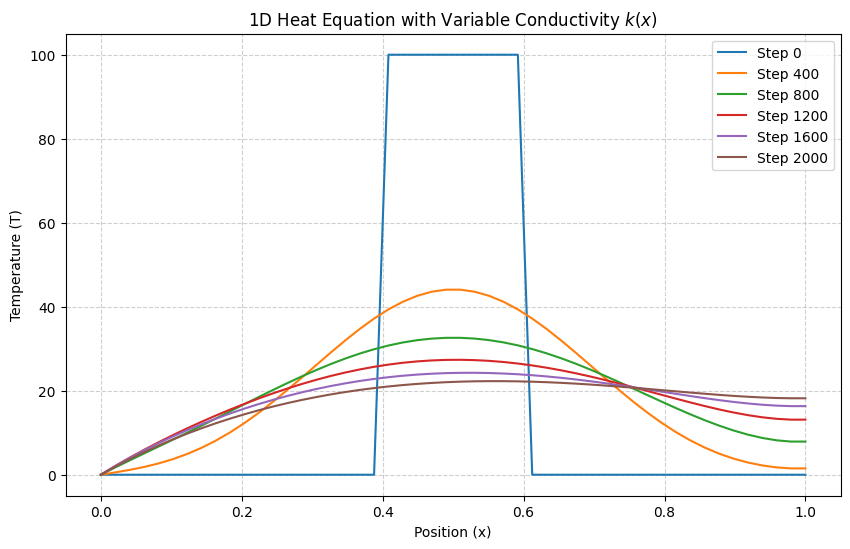

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def apply_bc(T):
    T[0] = 0        # Dirichlet: Fixed at 0
    T[-1] = T[-2]   # Neumann: Insulated (Zero gradient)

def solve_heat(nx=50, lx=1.0, alpha_base=1e-4, dt=0.1, nt=1000):
    dx = lx / (nx - 1)
    x = np.linspace(0, lx, nx)

    # Variable alpha calculation: alpha(x) = alpha_base * (1 + sin(pi*x))
    # We find the maximum to check stability
    alphas = alpha_base * (1 + np.sin(np.pi * x))
    alpha_max = np.max(alphas)

    dt_max = (dx**2) / (2 * alpha_max)

    if dt > dt_max:
        print(f"Warning: dt ({dt:.4e}) exceeds dt_max ({dt_max:.4e}). Expecting instability.")

    # Initial Condition: Square pulse in the middle
    T = np.zeros(nx)
    T[int(nx*2/5):int(nx*3/5)] = 100

    history = [T.copy()]

    for n in range(nt):
        Tn = T.copy()

        # Central difference for second derivative
        d2T_dx2 = (Tn[2:] - 2 * Tn[1:-1] + Tn[:-2]) / dx**2

        # Central difference for first derivative (for the k' term)
        dT_dx = (Tn[2:] - Tn[:-2]) / (2 * dx)

        # Derivative of alpha(x): alpha'(x) = alpha_base * pi * cos(pi*x)
        d_alpha_dx = alpha_base * np.pi * np.cos(np.pi * x[1:-1])

        # Update equation: dT/dt = alpha(x) * T'' + alpha'(x) * T'
        T[1:-1] = Tn[1:-1] + dt * (alphas[1:-1] * d2T_dx2 + d_alpha_dx * dT_dx)

        apply_bc(T)
        history.append(T.copy())

    return x, np.array(history)

# --- Execution and Plotting ---
x, history = solve_heat(nt=2000, dt=0.2)

plt.figure(figsize=(10, 6))
# Plot every 400 time steps to see progression
for i in range(0, len(history), 400):
    plt.plot(x, history[i], label=f'Step {i}')

plt.title("1D Heat Equation with Variable Conductivity $k(x)$")
plt.xlabel("Position (x)")
plt.ylabel("Temperature (T)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

